# Q4 — Regeneration (centronucleation), the laminin scaffold, and a cross-review

This notebook answers three follow-up questions on the QUA single-fibre data, on the **same
precomputed, unbiased clustering** used in Q1–Q3 (morphology + HE → PCA30 → UMAP → deterministic
GMM k=6, seed=42; no re-clustering). Per-animal statistics; observed values only; slide-8 excludes AAV9.

- **Part A — Cross-review** of the independent *Qwen* analysis on `main`.
- **Part B — Centronucleated fibres**: define them, quantify them, and ask *how regeneration relates
  to gene transfer and phenotype*.
- **Part C — Laminin vs dystrophin**: does dystrophin restoration *restore laminin*, or is laminin a
  pre-existing scaffold that (with dystrophin) enables function?

**Headline results.** (1) Regenerated (centronucleated) fibres are the disease population and are
**reduced by therapy (mdx 68% → AAV9 56% → LICA1 49%)**; (2) in treated muscle they carry **less
transgene dystrophin** — a fibre-intrinsic *regeneration penalty* independent of the laminin scaffold,
giving a **two-factor model** of restoration; (3) **laminin is dystrophin-independent** (present in mdx,
not raised by restoring dystrophin) — so it is the permissive anchor, *not* a downstream consequence.

### 0 · Setup (self-contained, reproducible)

In [1]:
# === Self-contained, reproducible setup (no /DATA symlink, no external bundle) ===
# Reproduces the analysis matrix from the repo's PRECOMPUTED UMAP cache.
# Clustering (PCA+UMAP) is NOT re-run: we load the cached embedding and reproduce
# only the deterministic GMM labelling (random_state=42), exactly as the repo's
# plot_umap.py does. This guarantees the same 6 clusters every run.
import os, sys, pickle, warnings, hashlib
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

# ---- locate repo root (works from scripts/, notebooks/, or repo root) ----
def find_repo_root():
    for base in [Path.cwd()] + list(Path.cwd().parents):
        if (base / "config" / "ddc_config.py").exists() and (base / "results" / "QUA").exists():
            return base
    for cand in [Path("/home/user/F2FMatcher_DDC"), Path("/DATA/F2FMatcher_DDC")]:
        if (cand / "config" / "ddc_config.py").exists():
            return cand
    raise RuntimeError("Cannot locate F2FMatcher_DDC repo root")
REPO = find_repo_root()
sys.path.insert(0, str(REPO))
from config.ddc_config import (SLIDES, MASK_FEATURES, QUA_SAMPLES, GROUP_MAP,
                               get_group, FEATURE_STATISTICS, ANALYSIS_CONFIG)

MUSCLE = "QUA"
RES = REPO / "results" / MUSCLE
COMBINED = RES / "features_combined"
CACHE = RES / "clustering_cache" / "ch3_zscore_pca30_mindist0.0_nn15.npz"
COMPARTMENT_ORDER = ["whole", "mem", "cyto1", "cyto2"]
RANDOM_STATE = ANALYSIS_CONFIG["random_state"]   # 42
GROUPS = ["WT", "mdx", "AAV9", "LICA1"]
GCOL = {"WT": "#0000C0", "mdx": "#FF6000", "AAV9": "#C0C000", "LICA1": "#008000"}
CLUSTER_COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]
CLUSTERS = [1, 2, 3, 4, 5, 6]
K = 6

def feature_columns():
    """807-col combined vector layout: 15 mask + 36 per channel (22 channels)."""
    cols = list(MASK_FEATURES)
    for slide in SLIDES:
        for ch, stain in SLIDES[slide]["stainings"].items():
            for comp in COMPARTMENT_ORDER:
                for stat in FEATURE_STATISTICS:
                    cols.append(f"S{slide}_{stain}_{comp}_{stat}")
    return cols

def slide_channel_blocks():
    blocks, off = {}, 0
    for slide in SLIDES:
        n = len(SLIDES[slide]["stainings"]); blocks[slide] = (off, n); off += n
    return blocks

def load_all_full():
    """Full 807-feature matrix for all QUA fibers (row order == cluster cache order)."""
    frames = []
    for s in QUA_SAMPLES:
        with open(COMBINED / f"{s}.pkl", "rb") as f:
            d = pickle.load(f)
        for lid, vec in d.items():
            frames.append(list(vec) + [lid, s, get_group(s)])
    cols = feature_columns() + ["label_id", "sample", "group"]
    return pd.DataFrame(frames, columns=cols)

def build_analysis_frame(verbose=True):
    """Load precomputed UMAP cache, reproduce GMM(k=6) labels, align full features.
    Cached to results/QUA/clustering_cache/analysis_frame_ch3_k6.npz for fast re-runs."""
    from sklearn.mixture import GaussianMixture
    fast = CACHE.parent / "analysis_frame_ch3_k6.npz"
    z = np.load(CACHE, allow_pickle=True)
    Xpca = z["X_pca"]; Xumap = z["X_umap"]
    groups = z["groups"].astype(str); samples = z["samples"].astype(str)
    # deterministic GMM labelling on the cached PCA embedding (same as plot_umap.py)
    labels = GaussianMixture(n_components=K, covariance_type="full", n_init=1,
                             max_iter=200, random_state=RANDOM_STATE).fit_predict(Xpca) + 1
    if fast.exists():
        c = np.load(fast, allow_pickle=True)
        if np.array_equal(c["samples"].astype(str), samples) and np.array_equal(c["labels"], labels):
            if verbose: print(f"Loaded aligned analysis frame from {fast.name}")
            return dict(Xpre=c["Xpre"], Xumap=Xumap, groups=groups, samples=samples,
                        labels=labels, cols=[str(x) for x in c["cols"]])
    df = load_all_full()
    full_cols = feature_columns()
    Xfull = df[full_cols].to_numpy(np.float64)
    blocks = slide_channel_blocks()
    # ch3 detection filter: fiber detected on slide 6 (HE) — reproduces the cache's rows
    st, nc = blocks[6]
    detected = (~np.isnan(Xfull[:, 15 + st*36:15 + (st+nc)*36])).any(axis=1)
    keep = detected >= 1
    Xpre = Xfull[keep]
    assert np.array_equal(df["sample"].to_numpy()[keep], samples), "row alignment mismatch"
    np.savez_compressed(fast, Xpre=Xpre, cols=np.array(full_cols),
                        samples=samples, labels=labels)
    if verbose: print(f"Built & cached aligned analysis frame -> {fast.name}")
    return dict(Xpre=Xpre, Xumap=Xumap, groups=groups, samples=samples,
                labels=labels, cols=full_cols)


In [2]:
# === Analysis helpers: marker panel, per-fiber values, per-animal statistics ===
import numpy as np, pandas as pd
from scipy import stats

# marker -> (column or [RGB cols], short biological meaning)
MARKERS = {
    "area":            ("area", "fiber cross-sectional area (size)"),
    "roundness":       ("roundness", "circularity"),
    "eccentricity":    ("eccentricity", "elongation"),
    "solidity":        ("solidity", "convexity"),
    "minor_axis":      ("minor_axis_length", "min Feret diameter"),
    "Dystrophin_mem":  ("S1_Dystrophin_mem_mean", "sarcolemmal dystrophin"),
    "Laminin_mem":     ("S1_Laminin_mem_mean", "basal-lamina laminin"),
    "Collagen4_mem":   ("S1_Collagen4_mem_mean", "peri-fiber collagen-IV / fibrosis"),
    "DAPI_cyto2":      ("S1_DAPI_cyto2_mean", "central nucleation (regeneration)"),
    "DAPI_mem":        ("S1_DAPI_mem_mean", "peripheral (normal) nuclei"),
    "IgG_whole":       ("S2_IgG_whole_mean", "IgG influx (necrosis / leaky sarcolemma)"),
    "CD11b_mem":       ("S2_CD11b_mem_mean", "CD11b+ myeloid infiltration"),
    "NADH":            (["S3_R_whole_mean","S3_G_whole_mean","S3_B_whole_mean"], "NADH-TR (oxidative; ↑=more oxidative here)"),
    "COX":             (["S7_R_whole_mean","S7_G_whole_mean","S7_B_whole_mean"], "COX (oxidative; ↑=more oxidative here)"),
    "Myh7":            ("S4_Myh7_whole_mean", "MyHC-I (slow oxidative)"),
    "Myh2":            ("S4_Myh2_whole_mean", "MyHC-IIa"),
    "Myh4":            ("S4_Myh4_whole_mean", "MyHC-IIb (fast glycolytic)"),
    "LAMP2":           ("S8_LAMP2_whole_mean", "LAMP2 (lysosomal membrane)"),
    "LGALS3":          ("S8_LGALS3_whole_mean", "galectin-3 (lysosomal damage)"),
    "SQSTM1":          ("S8_SQSTM1_whole_mean", "p62/SQSTM1 (autophagy)"),
    "HE_hematox_B":    ("S6_B_whole_mean", "HE hematoxylin (basophilia)"),
    "HE_eosin_R":      ("S6_R_whole_mean", "HE eosin"),
}
SLIDE8 = {"LAMP2", "LGALS3", "SQSTM1"}   # AAV9 mapping unreliable (15.7%) -> excluded

class QUA:
    """Bundles the analysis frame + marker accessors and per-animal statistics."""
    def __init__(self, D):
        self.Xpre = D["Xpre"]; self.Xumap = D["Xumap"]
        self.groups = D["groups"]; self.samples = D["samples"]; self.labels = D["labels"]
        self.cols = D["cols"]; self.cidx = {c: i for i, c in enumerate(self.cols)}
        self.usamp = np.unique(self.samples)
        self.sgroup = {s: self.groups[self.samples == s][0] for s in self.usamp}

    def mval(self, name):
        spec = MARKERS[name][0]
        if isinstance(spec, str):
            return self.Xpre[:, self.cidx[spec]]
        return np.nanmean(np.stack([self.Xpre[:, self.cidx[c]] for c in spec]), axis=0)

    def valid_groups(self, name):
        return [g for g in GROUPS if not (name in SLIDE8 and g == "AAV9")]

    def per_animal(self, name, cluster=None, stat="median"):
        """Per-animal summary (median by default) of observed marker; optional within-cluster."""
        v = self.mval(name); ok = ~np.isnan(v)
        if cluster is not None: ok = ok & (self.labels == cluster)
        rows = []
        for s in self.usamp:
            m = ok & (self.samples == s)
            if m.sum() >= 10:
                val = np.median(v[m]) if stat == "median" else np.mean(v[m])
                rows.append((s, self.sgroup[s], val, int(m.sum())))
        return pd.DataFrame(rows, columns=["sample", "group", "val", "n"])

    def cluster_fraction(self):
        rows = []
        for s in self.usamp:
            m = self.samples == s
            r = {"sample": s, "group": self.sgroup[s]}
            for c in CLUSTERS: r[f"Cls{c}"] = (self.labels[m] == c).mean() * 100
            rows.append(r)
        return pd.DataFrame(rows)

def cohens_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2: return np.nan
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

def mwu(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2: return np.nan
    try: return stats.mannwhitneyu(a, b, alternative="two-sided").pvalue
    except ValueError: return np.nan

def spearman_masked(a, b, nmin=50):
    m = ~np.isnan(a) & ~np.isnan(b)
    if m.sum() < nmin: return np.nan, int(m.sum())
    return stats.spearmanr(a[m], b[m]).correlation, int(m.sum())

def stars(p):
    if p is None or np.isnan(p): return "n/a"
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"


In [3]:
# === Q4 figures: centronucleation, two-factor restoration model, laminin causality ===
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
def _z(x): return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-9)

def compute_cn(q, pct=90):
    """Central-nucleation score = DAPI intensity variance in the DEEP core (cyto2).
    A central nucleus creates bright DAPI pixels in the otherwise-dark fibre core ->
    high std (WT median 0.5 vs mdx 4.6). cyto1 is avoided: it still holds normal
    peripheral nuclei. Threshold = WT p90 (~10% WT false-positive by construction)."""
    cn = q.Xpre[:, q.cidx["S1_DAPI_cyto2_std"]]
    thr = np.nanpercentile(cn[q.groups == "WT"], pct)
    return cn, thr, cn >= thr

def fig_cn_overview(q, flag, cn, thr, out):
    fig = plt.figure(figsize=(15, 4.4))
    # (a) score distribution WT vs mdx + threshold
    ax = fig.add_subplot(1, 3, 1)
    for g, c in [("WT", GCOL["WT"]), ("mdx", GCOL["mdx"])]:
        ax.hist(np.clip(cn[q.groups == g], 0, 15), bins=60, density=True, histtype="step",
                color=c, lw=1.8, label=g)
    ax.axvline(thr, ls="--", color="k", lw=1); ax.text(thr+.3, ax.get_ylim()[1]*.7, "CN+ threshold\n(WT p90)", fontsize=8)
    ax.set_xlabel("DAPI variance in deep core (cyto2 std)"); ax.set_ylabel("density")
    ax.set_title("(a) Central-nucleation score\nWT (peripheral nuclei) vs mdx", fontweight="bold", fontsize=10)
    ax.legend()
    # (b) per-animal CN+ prevalence
    ax = fig.add_subplot(1, 3, 2)
    for i, g in enumerate(GROUPS):
        vals = [flag[q.samples == s].mean()*100 for s in q.usamp if q.sgroup[s] == g]
        ax.bar(i, np.mean(vals), color=GCOL[g], alpha=.4, width=.6)
        ax.scatter([i]*len(vals), vals, color=GCOL[g], edgecolor="k", lw=.5, s=36, zorder=3)
        ax.hlines(np.mean(vals), i-.3, i+.3, color="k", lw=1.6)
    ax.set_xticks(range(4)); ax.set_xticklabels(GROUPS, rotation=15)
    ax.set_ylabel("% centronucleated fibres (per animal)")
    ax.set_title("(b) Regeneration burden falls with therapy\n(mdx 68% → LICA1 49%; LICA1 < AAV9)", fontweight="bold", fontsize=10)
    # (c) CN+ by cluster
    ax = fig.add_subplot(1, 3, 3)
    frac = [flag[q.labels == c].mean()*100 for c in CLUSTERS]
    ax.bar([f"Cls{c}" for c in CLUSTERS], frac, color=[CLUSTER_COLORS[c-1] for c in CLUSTERS])
    for i, f in enumerate(frac): ax.text(i, f+1.5, f"{f:.0f}%", ha="center", fontsize=8.5, fontweight="bold")
    ax.set_ylabel("% centronucleated fibres")
    ax.set_title("(c) Regenerated fibres define disease clusters\n(Cls5 resistant = 87%, Cls3 = 75%)", fontweight="bold", fontsize=9.5)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out

def fig_cn_transduction(q, flag, out):
    vd = q.mval("Dystrophin_mem")
    fig = plt.figure(figsize=(15, 4.5))
    # (a) dystrophin CN+ vs CN- by group
    ax = fig.add_subplot(1, 3, 1)
    W = .38
    for i, g in enumerate(GROUPS):
        m = (q.groups == g) & ~np.isnan(vd)
        ax.bar(i-W/2, np.median(vd[m & ~flag]), W, color=GCOL[g], alpha=.5)
        ax.bar(i+W/2, np.median(vd[m & flag]), W, color=GCOL[g], hatch="////", edgecolor="white")
    ax.set_xticks(range(4)); ax.set_xticklabels(GROUPS, rotation=15)
    ax.set_ylabel("membrane dystrophin (median)")
    ax.set_title("(a) In treated muscle, regenerated (CN+, hatched)\nfibres carry LESS transgene dystrophin", fontweight="bold", fontsize=9.5)
    ax.plot([], [], "s", color="gray", alpha=.5, label="CN− (not regen.)")
    ax.plot([], [], "s", color="gray", alpha=.99, markerfacecolor="none", label="CN+ (regenerated)")
    ax.legend(fontsize=8, loc="upper left")
    # (b) within-cluster Δ (LICA1)
    ax = fig.add_subplot(1, 3, 2)
    d = []
    for c in CLUSTERS:
        m = (q.groups == "LICA1") & (q.labels == c) & ~np.isnan(vd)
        a, b = vd[m & flag], vd[m & ~flag]
        d.append(np.median(a) - np.median(b) if len(a) > 20 and len(b) > 20 else np.nan)
    ax.bar([f"Cls{c}" for c in CLUSTERS], d,
           color=[("#d62728" if c == 5 else CLUSTER_COLORS[c-1]) for c in CLUSTERS])
    ax.axhline(0, color="k", lw=.8)
    ax.set_ylabel("Δ dystrophin (CN+ − CN−), LICA1")
    ax.set_title("(b) The regeneration penalty is fibre-intrinsic\n(holds within clusters; worst in Cls5)", fontweight="bold", fontsize=9.5)
    # (c) two-factor OLS
    ax = fig.add_subplot(1, 3, 3)
    preds = ["Laminin_mem", "Myh4", "area", "NADH"]
    m = ((q.groups == "AAV9") | (q.groups == "LICA1")) & ~np.isnan(vd)
    for p in preds: m &= ~np.isnan(q.mval(p))
    y = _z(vd[m]); X = sm.add_constant(np.column_stack([_z(q.mval(p)[m]) for p in preds] + [flag[m].astype(float)]))
    beta = sm.OLS(y, X).fit().params[1:]
    names = ["Laminin\n(scaffold)", "Myh4", "area", "NADH", "CN+ (regen.\npenalty)"]
    colors = ["#2ca02c", "#999", "#999", "#999", "#d62728"]
    ax.barh(range(len(names)), beta[::-1], color=colors[::-1])
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names[::-1], fontsize=8.5)
    ax.axvline(0, color="k", lw=.8); ax.set_xlabel("standardized β (predict membrane dystrophin)")
    ax.set_title("(c) Two independent factors:\nlaminin scaffold (+) & regeneration (−)", fontweight="bold", fontsize=9.5)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out

def fig_laminin_causality(q, out):
    vd, vl = q.mval("Dystrophin_mem"), q.mval("Laminin_mem")
    fig = plt.figure(figsize=(15, 4.5))
    # (a) per-animal dystrophin vs laminin by group (dystrophin moves, laminin doesn't)
    ax = fig.add_subplot(1, 3, 1)
    def pam(v): return {g: np.mean([np.median(v[(q.samples == s) & ~np.isnan(v)]) for s in q.usamp if q.sgroup[s] == g]) for g in GROUPS}
    dy, la = pam(vd), pam(vl)
    x = np.arange(4)
    ax.plot(x, [dy[g] for g in GROUPS], "o-", color="#2ca02c", lw=2, ms=8, label="Dystrophin (membrane)")
    ax.plot(x, [la[g] for g in GROUPS], "s--", color="#8c564b", lw=2, ms=8, label="Laminin (basal lamina)")
    ax.axvspan(-.4, .4, color="#0000C0", alpha=.05)
    ax.set_xticks(x); ax.set_xticklabels(GROUPS, rotation=15); ax.set_ylabel("per-animal median (a.u.)")
    ax.legend(fontsize=8.5)
    ax.set_title("(a) Dystrophin is lost & restored;\nLaminin stays flat (dystrophin-independent)", fontweight="bold", fontsize=9.5)
    # (b) 2x2 healthy membership by laminin x dystrophin
    ax = fig.add_subplot(1, 3, 2)
    vi = q.mval("IgG_whole")
    tm = ((q.groups == "AAV9") | (q.groups == "LICA1")) & ~np.isnan(vl) & ~np.isnan(vd)
    lam_hi = vl >= np.nanmedian(vl[tm]); dys_hi = vd >= np.nanmedian(vd[tm])
    healthy = np.isin(q.labels, [4, 6])
    M = np.array([[healthy[tm & ~lam_hi & ~dys_hi].mean(), healthy[tm & ~lam_hi & dys_hi].mean()],
                  [healthy[tm & lam_hi & ~dys_hi].mean(), healthy[tm & lam_hi & dys_hi].mean()]])*100
    im = ax.imshow(M, cmap="Greens", vmin=0, vmax=55)
    for i in range(2):
        for j in range(2): ax.text(j, i, f"{M[i,j]:.0f}%", ha="center", va="center", fontsize=14, fontweight="bold",
                                   color="white" if M[i,j] > 30 else "k")
    ax.set_xticks([0,1]); ax.set_xticklabels(["Dys LOW","Dys HIGH"]); ax.set_yticks([0,1]); ax.set_yticklabels(["Lam LOW","Lam HIGH"])
    ax.set_title("(b) % fibres in healthy clusters (treated)\nDystrophin drives it; laminin alone doesn't", fontweight="bold", fontsize=9.5)
    # (c) WT endogenous dystrophin~laminin (native DGC also tracks laminin)
    ax = fig.add_subplot(1, 3, 3)
    m = (q.groups == "WT") & ~np.isnan(vd) & ~np.isnan(vl)
    ax.hexbin(vl[m], vd[m], gridsize=40, cmap="Blues", bins="log", mincnt=1)
    from scipy.stats import spearmanr
    r = spearmanr(vl[m], vd[m]).correlation
    ax.set_xlabel("Laminin_mem"); ax.set_ylabel("Dystrophin_mem (endogenous)")
    ax.set_xlim(np.nanpercentile(vl[m],1), np.nanpercentile(vl[m],99)); ax.set_ylim(np.nanpercentile(vd[m],1), np.nanpercentile(vd[m],99))
    ax.set_title(f"(c) Even native dystrophin tracks laminin\n(WT r={r:.2f}) — the DGC anchor, not a consequence", fontweight="bold", fontsize=9.5)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out


In [4]:
from IPython.display import Image
D = build_analysis_frame(); q = QUA(D)
cn, thr, flag = compute_cn(q)           # centronucleation score, WT-p90 threshold, CN+ boolean
print(f"Fibers: {len(q.labels):,} | CN+ threshold (WT p90 of DAPI cyto2 std) = {thr:.2f} | overall CN+ = {flag.mean()*100:.1f}%")


Loaded aligned analysis frame from analysis_frame_ch3_k6.npz


Fibers: 111,403 | CN+ threshold (WT p90 of DAPI cyto2 std) = 1.73 | overall CN+ = 42.3%


## Part A — Cross-review of the independent *Qwen* analysis (`main`)

The `main` branch carries an independent analysis (Qwen) of the same two questions. It uses the
**same reproducible foundation** as this work — the same precomputed `ch3` cache and the *same*
deterministic GMM (k=6, full covariance, `n_init=1`, `random_state=42`) — so its clusters **C1–C6 are
identical** to ours. This is a strong mutual validation: two independent agents, same pipeline, same states.

### Where we agree (independent convergence — high confidence)
- **Dystrophin loss is universal and severe** in mdx, in every cluster (Qwen Cliff δ≈0.75; ours Cohen d≈−3.5).
- **Fibre-state shift**: mdx loses healthy C4/C6 and gains diseased C2/C3/C5 — identical numbers.
- **LICA1 ≫ AAV9 in every cluster** for membrane dystrophin; both clear C2/C3 and recover C4/C6, LICA1 more.
  Qwen's *dystrophin-deficient fraction* (mdx 79–99% → AAV9 41–68% → LICA1 10–36%) is the mirror image of
  our *fraction reaching WT* (mdx 3% → AAV9 28% → LICA1 65%).
- **C5 is the resistant state**; and crucially Qwen reaches **our exact Q3 conclusion**: *"within C5, LICA1
  still restores dystrophin (29→53, above WT) — the transgene works; what resists is the morphological/HE
  phenotype."* Independent arrival at *molecular ≠ morphological rescue*.
- **Lost correlation** `Myh7~NADH 0.88→0.67` — identical value in both analyses.

### Where we differ / points to flag
1. **Fibre-type nomenclature error in Qwen.** Qwen labels **Myh7 as "fast"** and **Myh4 as "IIx"** and calls
   the mdx shift *"fast-to-oxidative."* This is inverted: **Myh7 = MyHC-I (slow, oxidative, type I)** and
   **Myh4 = MyHC-IIb (fast, glycolytic)**. The *directions* Qwen reports (Myh7↓, Myh4↑) are correct, but the
   *labels/interpretation* ("fast-to-oxidative") are backwards — it is a slow→fast (oxidative→glycolytic)
   myosin shift. Our notebooks use the correct nomenclature (verified with the user).
2. **Qwen's C5 "impaired uptake" inference is partly contradicted by the data.** Qwen speculates C5 resists
   because "BM defect / large size lowers transduction (uptake)." But both analyses show **LICA1 restores C5
   dystrophin *above* WT** — i.e. delivery/expression is *not* the failure in C5. Our Q3/Q4 localize the
   resistance to *architecture* (fast-glycolytic remodelled morphology) and, for the *degree* of transgene,
   to *regeneration* (Part B) — not to a laminin/size uptake barrier.
3. **A slide-8 claim on AAV9 that should be excluded.** Qwen reports "AAV9 *worsens* LAMP2~SQSTM1 (0.59)",
   but AAV9 slide-8 mapping is ~16% (only 1/4 animals) — both analyses agree AAV9 must be excluded from
   slide-8. That specific AAV9 coupling number is unreliable.

### Complementary strengths
- **Qwen adds**: Cliff's-δ effect sizes; extra lost couplings (`NADH~area`, `DAPI~area`, `Laminin~WGA`,
  `LAMP2~SQSTM1`); per-sample dystrophin consistency.
- **This work adds**: per-animal Mann–Whitney inference; the **laminin-scaffold regression** (β≈0.75, R²≈0.5,
  collagen-IV control); the **literature synthesis** (confirmed vs novel); and, below, the **regeneration /
  two-factor** and **laminin-causality** analyses.

**Verdict.** The two independent analyses agree on every major conclusion — the core findings are robust.
Adopt Qwen's extra correlation panels and Cliff's-δ; **fix the Myh7/Myh4 nomenclature** and drop the AAV9
slide-8 coupling number; treat C5 resistance as architectural + regeneration-linked, not an uptake failure.

## Part B — Centronucleated (regenerated) fibres

**Definition.** In mature muscle myonuclei sit at the periphery (under the sarcolemma); a **central
nucleus** marks a fibre that has regenerated after a degeneration cycle. We score it from the DAPI channel
(slide 1, 100% coverage) as the **DAPI intensity variance in the deep fibre core (`cyto2`)**: a central
nucleus injects bright DAPI pixels into an otherwise-dark core, so `cyto2` std jumps (WT median 0.5 vs mdx
4.6). We deliberately **avoid `cyto1`**, which still contains normal *peripheral* nuclei just inside the
membrane. Threshold = WT p90 (so ~10% of WT fibres are CN+ by construction).

CN+ prevalence, per animal (mean%):
  WT     10.4%  (per-animal: 17, 9, 8, 8, 9)
  mdx    67.7%  (per-animal: 67, 66, 70, 70, 65)
  AAV9   55.8%  (per-animal: 65, 47, 61, 50)
  LICA1  48.7%  (per-animal: 52, 48, 51, 47, 46)


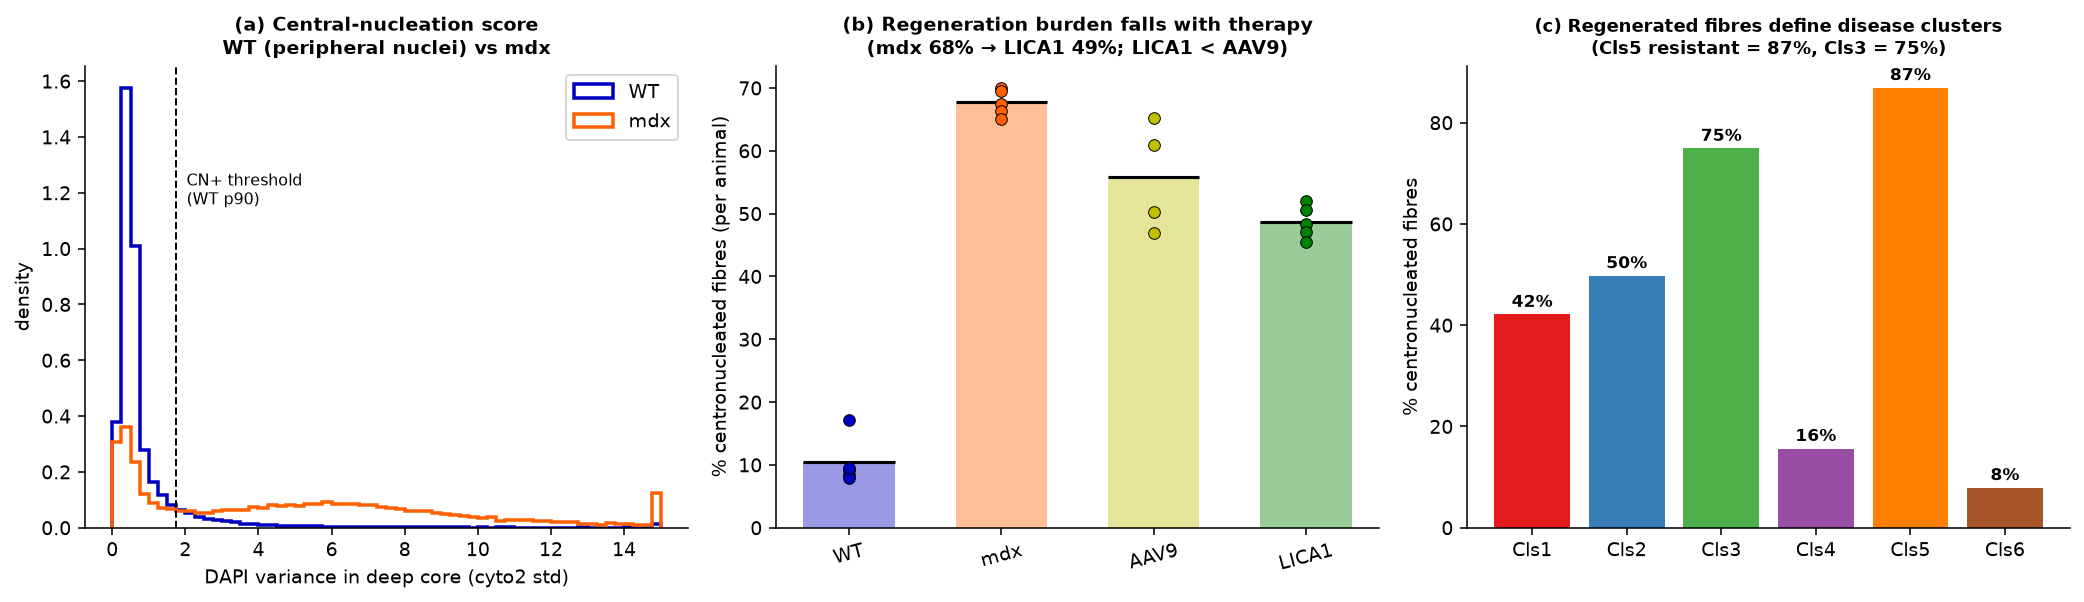

In [5]:
print("CN+ prevalence, per animal (mean%):")
for g in GROUPS:
    v=[flag[q.samples==s].mean()*100 for s in q.usamp if q.sgroup[s]==g]
    print(f"  {g:6s} {np.mean(v):4.1f}%  (per-animal: {', '.join(f'{x:.0f}' for x in v)})")
fig_cn_overview(q, flag, cn, thr, "fig_q4_cn_overview.png"); Image("fig_q4_cn_overview.png")

**Result — regeneration burden tracks disease and therapy:**
- **WT 10% → mdx 68% → AAV9 56% → LICA1 49%** centronucleated (per animal). mdx muscle is dominated by
  regenerated fibres; **both therapies reduce it, LICA1 more than AAV9** — fewer degeneration–regeneration
  cycles = disease slowing.
- Centronucleation **defines the disease clusters**: the resistant **Cls5 is 87%** regenerated and **Cls3
  is 75%**, whereas the healthy WT-like **Cls4/Cls6 are 8–16%**. The healthy clusters are largely
  *never-damaged / peripheral-nucleated* fibres; the pathological clusters are *regenerated* fibres.

Membrane dystrophin: CN- vs CN+ (median) by group
  WT     CN-  50.1 | CN+  52.2 | Δ(CN+−CN-)  +2.1
  mdx    CN-  30.1 | CN+  31.9 | Δ(CN+−CN-)  +1.8
  AAV9   CN-  42.1 | CN+  37.6 | Δ(CN+−CN-)  -4.5
  LICA1  CN-  62.5 | CN+  57.7 | Δ(CN+−CN-)  -4.7


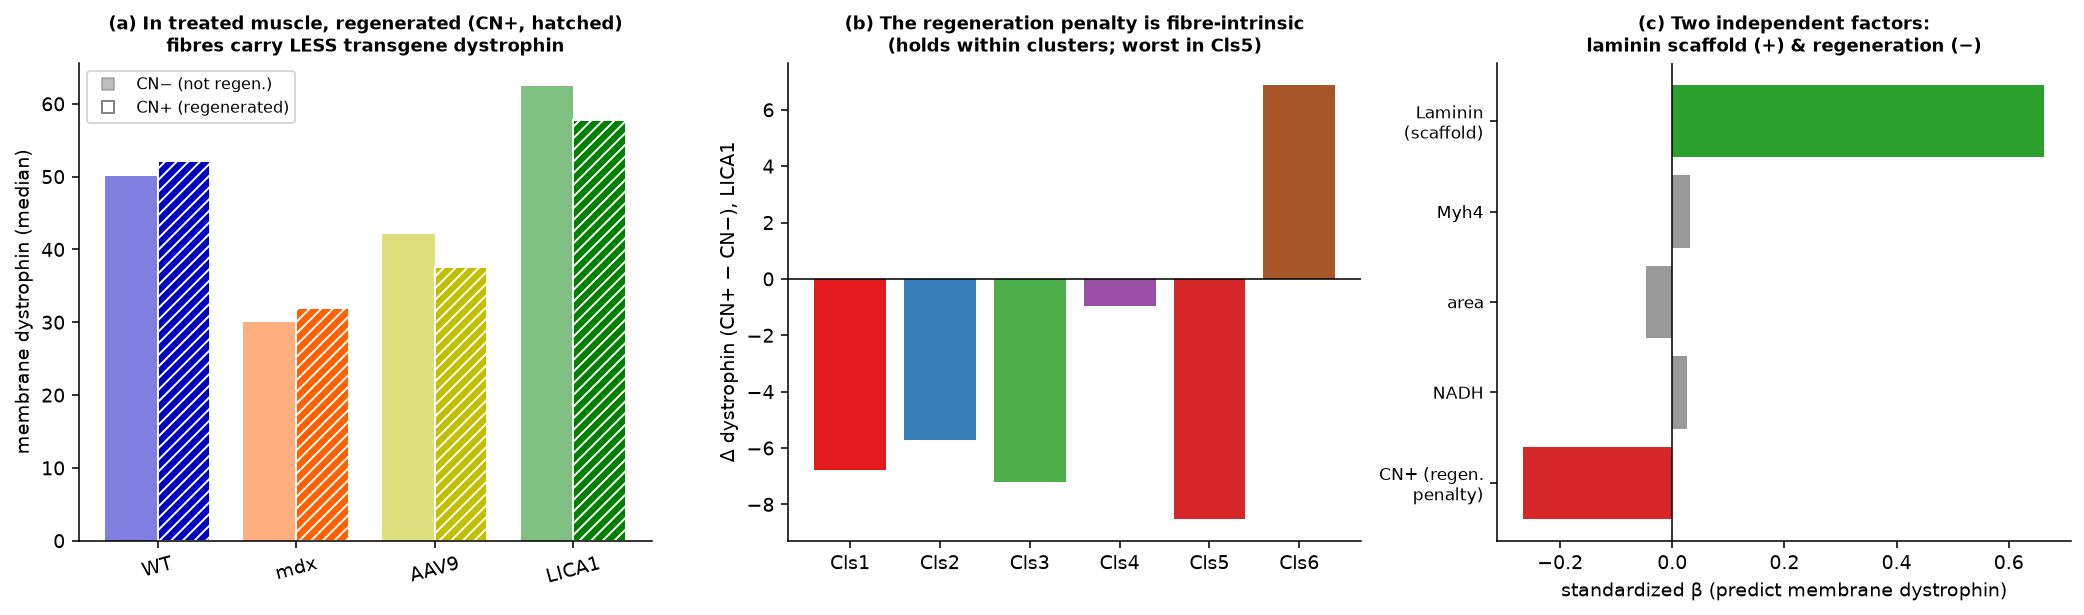

In [6]:
vd=q.mval("Dystrophin_mem")
print("Membrane dystrophin: CN- vs CN+ (median) by group")
for g in GROUPS:
    m=(q.groups==g)&~np.isnan(vd)
    print(f"  {g:6s} CN- {np.median(vd[m&~flag]):5.1f} | CN+ {np.median(vd[m&flag]):5.1f} | Δ(CN+−CN-) {np.median(vd[m&flag])-np.median(vd[m&~flag]):+5.1f}")
fig_cn_transduction(q, flag, "fig_q4_cn_transduction.png"); Image("fig_q4_cn_transduction.png")

**Result — regeneration vs gene transfer (a new, mechanistic finding):**
- In **WT/mdx** (no transgene), CN+ fibres have *slightly higher* dystrophin (regenerated fibres still make
  endogenous protein). **In treated muscle the sign flips**: CN+ (regenerated) fibres carry **less transgene
  dystrophin** (AAV9 −4.5, LICA1 −4.7; LICA1 negative in all 5 animals).
- It is **fibre-intrinsic**: the penalty holds *within* clusters (LICA1 Δ −6 to −8.5), worst in the resistant
  **Cls5 (−8.5)**. In a standardized regression, **CN+ is an independent negative predictor (β≈−0.27)** of
  membrane dystrophin, *on top of* the laminin scaffold (β≈+0.66) — the two axes are separate (CN+ fibres
  have **normal laminin**).

**Mechanism (two factors + a feedback loop).** AAV genomes are **episomal (non-integrating)**; they are
**lost/diluted during regeneration** — a regenerated fibre is built partly from satellite cells that never
carried the vector, and each cycle dilutes the transgene. So a fibre's restored dystrophin is limited by
**(1) the laminin/basal-lamina scaffold** (where it can anchor) and **(2) its regeneration history** (how
much vector it still carries). Critically, this is a **feedback loop**: only *sufficient* dystrophin arrests
the degeneration–regeneration cycle and thereby *stabilises* the vector — sub-optimal restoration keeps the
cycle running and keeps losing genome. This is exactly why **LICA1** (stronger restoration) shows **less
regeneration (49% vs 56%)** and more durable-looking restoration, and why the **highly-regenerating,
under-transduced Cls5** stays resistant.

## Part C — Laminin vs dystrophin: which causes which?

We found membrane dystrophin tracks laminin very tightly (r≈0.75; Q3). The question: did **dystrophin
restoration *restore* laminin** (dystrophin → laminin), or is **laminin a pre-existing scaffold** that,
together with delivered dystrophin, yields function (laminin → dystrophin → function)? Cross-sectional data
can't prove causation, but three tests separate the hypotheses.

per-animal medians:      WT     mdx    AAV9   LICA1
  Dystrophin_mem    49.8   30.6   41.7   58.3   (mdx≪WT, restored by LICA1)
  Laminin_mem       40.2   37.6   39.0   38.7   (mdx≈WT, flat across treatment)


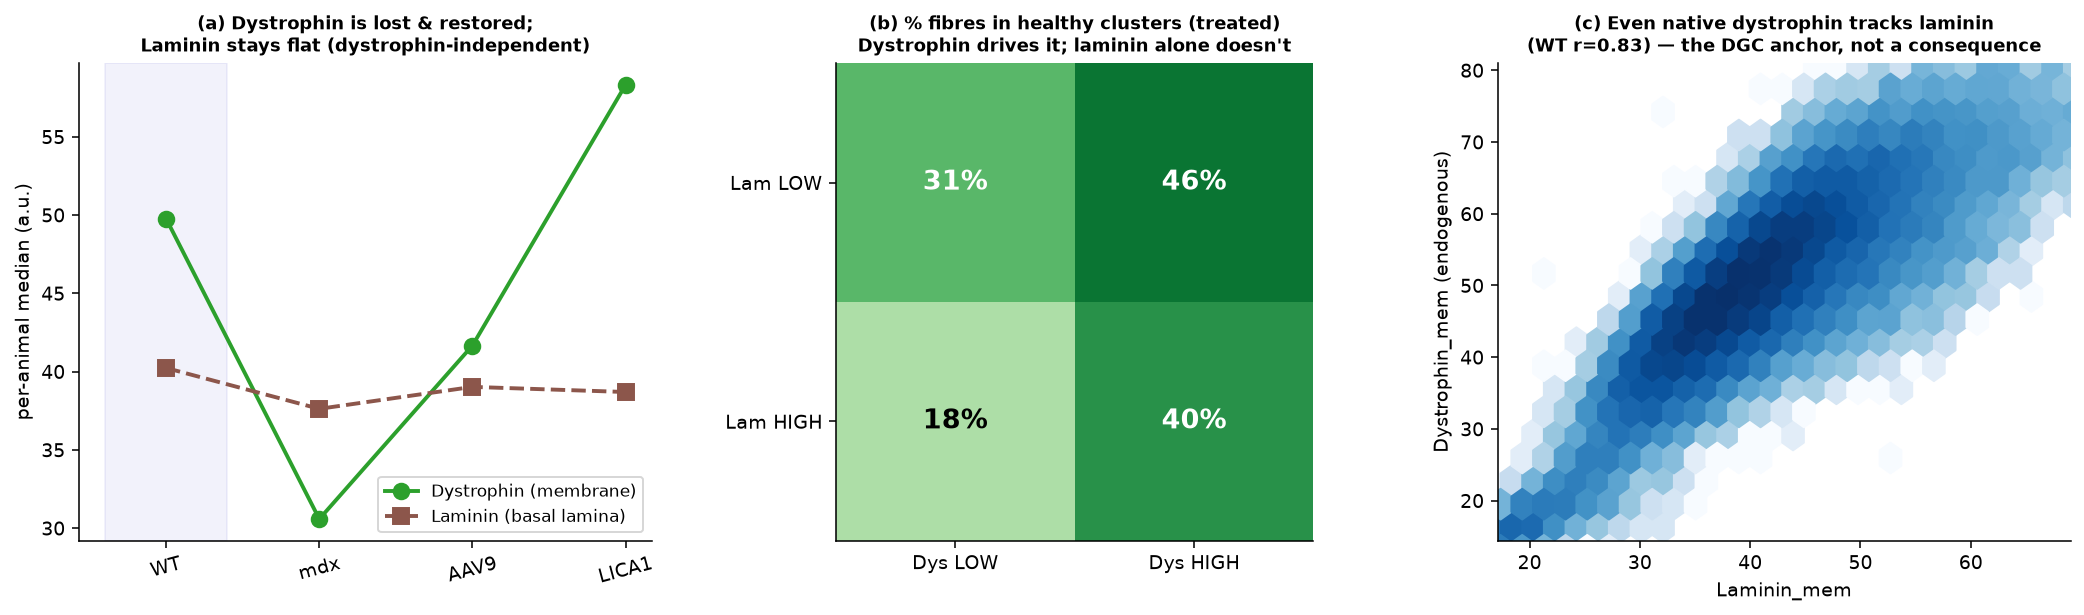

In [7]:
vl=q.mval("Laminin_mem")
def pam(v): return {g:np.mean([np.median(v[(q.samples==s)&~np.isnan(v)]) for s in q.usamp if q.sgroup[s]==g]) for g in GROUPS}
dy,la=pam(vd),pam(vl)
print("per-animal medians:      WT     mdx    AAV9   LICA1")
print("  Dystrophin_mem  " + " ".join(f"{dy[g]:6.1f}" for g in GROUPS) + "   (mdx≪WT, restored by LICA1)")
print("  Laminin_mem     " + " ".join(f"{la[g]:6.1f}" for g in GROUPS) + "   (mdx≈WT, flat across treatment)")
fig_laminin_causality(q, "fig_q4_laminin.png"); Image("fig_q4_laminin.png")

**Answer — laminin is the pre-existing scaffold, *not* a consequence of dystrophin:**
1. **Test 1 — is laminin lost when dystrophin is absent?** No. Dystrophin collapses in mdx (50→31, d≈−3.5)
   but **laminin barely changes** (40.2→37.6, d≈−0.5). The basal lamina persists in fully dystrophin-null
   muscle → laminin does **not** depend on dystrophin. (WGA, a second BM/membrane marker, behaves the same.)
2. **Test 2 — does restoring dystrophin raise laminin?** No. LICA1 restores dystrophin massively (31→58,
   p=0.008) yet **laminin does not move** (37.6→38.7, d≈+0.16, p=0.69). So *"dystrophin restoration restored
   laminin" is false* — panel (a): the dystrophin curve dives and rebounds while laminin stays flat.
3. **Test 3 — does laminin alone give the healthy phenotype, or is dystrophin needed?** Panel (b): within
   each laminin stratum, **higher dystrophin drives fibres into healthy clusters** (Dys LOW→HIGH: 31→46% and
   18→40%); **laminin alone (Lam-high, Dys-low) does not** (18%). Laminin is *necessary scaffold, not
   sufficient driver*. Panel (c): even **native WT dystrophin tracks laminin (r=0.83)** — laminin is the DGC
   anchor for endogenous *and* transgene dystrophin.

> Caveat: the *membrane-laminin intensity* is higher in small/regenerating fibres (surface-to-volume), which
> confounds the laminin *rows* of panel (b); the causal reading rests on tests 1–2 (a,c), which are clean.

**So the correct statement is:** *laminin (a pre-existing, dystrophin-independent basal-lamina scaffold) +
delivered dystrophin → membrane repair and the healthy phenotype.* Dystrophin does not create laminin; it
uses it. This also reframes therapy: where the basal lamina is intact, µDys anchors and works; augmenting the
scaffold (e.g. laminin-111, α7β1-integrin) could widen the fraction of fibres that can be rescued.

## Synthesis & literature (confirmed vs newly discovered)

**Integrated model of micro-dystrophin restoration at single-fibre resolution:**
a restored fibre needs **(i) an intact laminin/basal-lamina scaffold** (permissive anchor; β≈+0.75) and
**(ii) enough retained vector**, which is set by its **regeneration history** (CN+ penalty β≈−0.27) — and the
two are linked by a **feedback loop** in which sufficient dystrophin arrests regeneration and stabilises the
episome. The **resistant Cls5** fails on architecture (fast-glycolytic remodelled morphology) *and* sits in
the high-regeneration / high-dilution regime.

| Finding (this data) | Status | Literature |
|---|---|---|
| Central nucleation = regeneration marker; dominates dystrophic muscle | **Confirmed** | classic DMD/mdx histopathology |
| **Regenerated (CN+) fibres carry less transgene dystrophin, fibre-intrinsically** | **Newly discovered (in-situ, single-fibre)** | mechanism = AAV episome dilution/loss with regeneration — Le Hir 2013 |
| Sufficient dystrophin arrests the dystrophic cycle and *stabilises* AAV genome; sub-optimal does not | **Confirmed (mechanism)** | Le Hir 2013 |
| Therapy lowers regeneration burden (mdx 68%→LICA1 49%), LICA1>AAV9 | **Confirmed direction; newly quantified per-fibre** | durability literature |
| **Laminin is dystrophin-independent** (present in mdx; not raised by µDys) — the permissive anchor | **Newly shown here**; consistent with DGC biology | Gumerson & Michele 2011 |
| Laminin necessary but not sufficient; dystrophin drives the healthy phenotype | **Newly shown here** | DGC biology |

**Verified citations (PubMed):**
1. Le Hir M, *et al.* *AAV genome loss from dystrophic mouse muscles during AAV-U7 snRNA-mediated exon-skipping therapy.* Mol Ther. 2013;21(8):1551-8. [DOI](https://doi.org/10.1038/mt.2013.121) · PMID 23752313
2. Gumerson JD, Michele DE. *The dystrophin-glycoprotein complex in the prevention of muscle damage.* J Biomed Biotechnol. 2011;2011:210797. [DOI](https://doi.org/10.1155/2011/210797) · PMID 22007139
3. Weinmann J, *et al.* *Identification of a myotropic AAV…(AAVMYO).* Nat Commun. 2020;11:5432. [DOI](https://doi.org/10.1038/s41467-020-19230-w) · PMID 33116134
4. Bonato A, *et al.* *…oxidative phenotype ameliorates mdx pathophysiology.* FASEB J. 2023;37(7):e23025. [DOI](https://doi.org/10.1096/fj.202201769R) · PMID 37309599

## Conclusions
1. **Centronucleated fibres are the regenerated disease population** — reduced by therapy (LICA1 > AAV9), and
   they define the resistant/regenerating clusters (Cls5 87%, Cls3 75%).
2. **Regeneration limits gene transfer**: CN+ fibres carry less transgene dystrophin, independently of the
   laminin scaffold — a two-factor (scaffold × vector-retention) model with a dystrophin↔regeneration feedback
   loop. Practical implication: **start early** and **maximise per-fibre dose/potency** (favouring LICA1) to
   break the loop; satellite-cell-targeting vectors would address the durability gap.
3. **Laminin is a pre-existing, dystrophin-independent scaffold**, not restored by dystrophin. The right
   causal statement is *laminin + dystrophin → function*; augmenting the basal lamina could enlarge the
   rescuable fibre pool.
4. **The independent Qwen analysis agrees on all major conclusions** (mutual validation); we flag only its
   fibre-type nomenclature inversion and one unreliable AAV9 slide-8 number.

**Caveats:** n = 4–5 animals/group; single time-point (durability/feedback inferred + literature, not a time
course); correlations are observational; laminin & dystrophin share the membrane ROI (controlled via the
collagen-IV null and the dystrophin-independence tests); mouse muscle is IIb-rich vs human (translational note).